# Phase 3 — Clustering & Visualisation

Before supervised modelling, we use **k-means (k = 2)** as a diagnostic: with labels hidden, do the clips fall into
natural groups that match the two scales? We then visualise the feature space with **PCA**.

*Concepts used: standardisation, k-means, PCA — all covered in the course.*

In [1]:
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Anchor to project root: works whether run from repo root or notebooks/.
# Figures/features go to the SHARED root folders (same as the src/ scripts).
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
RAW  = ROOT / 'data' / 'raw'
FEAT = ROOT / 'features'; FEAT.mkdir(exist_ok=True)
FIG  = ROOT / 'figures';  FIG.mkdir(exist_ok=True)
X = np.load(FEAT/'X.npy')
y = np.load(FEAT/'y.npy', allow_pickle=True)
print('data:', X.shape)

data: (306, 64)


## 3.1  Standardise
Features span very different ranges; standardising (zero mean, unit variance) prevents large-valued features from dominating distance-based methods like k-means and PCA.

In [2]:
Xs = StandardScaler().fit_transform(X)

## 3.2  k-means (k = 2) and comparison to true scales
We compare the unsupervised cluster assignment against the true labels with a simple crosstab.

In [3]:
import pandas as pd
km = KMeans(n_clusters=2, n_init=10, random_state=42).fit(Xs)
tab = pd.crosstab(pd.Series(y, name='true'), pd.Series(km.labels_, name='cluster'))
print(tab)
print('\nIf clusters matched scales, each cluster would be almost all one scale.')

cluster   0    1
true            
bati     53   91
tizita   42  120

If clusters matched scales, each cluster would be almost all one scale.


## 3.3  Same test on feature subsets
Repeat using only chroma or only MFCC columns, to see whether either family separates the scales on its own.

In [4]:
cols  = [f'mfcc{i}_mean' for i in range(20)] + [f'mfcc{i}_std' for i in range(20)]
cols += [f'chroma{i}_mean' for i in range(12)] + [f'chroma{i}_std' for i in range(12)]
cols = np.array(cols)
for name, mask in [('chroma only', np.char.startswith(cols.astype(str),'chroma')),
                   ('MFCC only',   np.char.startswith(cols.astype(str),'mfcc'))]:
    Xsub = StandardScaler().fit_transform(X[:, mask])
    lab = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(Xsub)
    print(f'\n{name}:')
    print(pd.crosstab(pd.Series(y, name='true'), pd.Series(lab, name='cluster')))


chroma only:
cluster   0   1
true           
bati     60  84
tizita   90  72

MFCC only:
cluster   0    1
true            
bati     58   86
tizita   45  117


## 3.4  PCA visualisation
Project the 64-D feature space onto its first two principal components (directions of greatest variance) and colour by true scale.
Heavy overlap indicates scale is **not** the dominant source of variation — consistent with the genre/recording confound.

variance explained: PC1 20.8%, PC2 8.2%


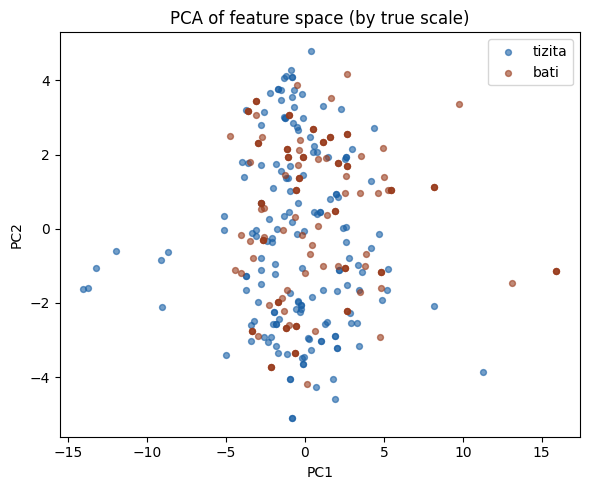

In [5]:
p = PCA(n_components=2).fit(Xs)
Z = p.transform(Xs)
print('variance explained: PC1 %.1f%%, PC2 %.1f%%' % tuple(100*p.explained_variance_ratio_[:2]))
plt.figure(figsize=(6,5))
for scale, color in [('tizita','#185FA5'), ('bati','#993C1D')]:
    m = y == scale
    plt.scatter(Z[m,0], Z[m,1], s=18, alpha=0.6, label=scale, color=color)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend(); plt.title('PCA of feature space (by true scale)')
plt.tight_layout(); plt.savefig(FIG/'pca_scatter.png', dpi=150); plt.show()

**Interpretation.** Clustering does not recover the scales and the PCA view shows heavy overlap: scale is subtle and buried under genre/recording variation. This does *not* doom supervised classification — the next phase tests whether labelled models can recover the signal.

---
**Next:** Phase 4 — supervised classification.